### Capstone Project: Book details

Provided dataset which was taken from Kaggle has information about various books with title, author, rating, no of ratings, no of reviews, description and genres. 

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)


In [ ]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd # type: ignore
import seaborn as sns # type: ignore
from sklearn.datasets import fetch_openml # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time

from sklearn.preprocessing import MultiLabelBinarizer # type: ignore


In [3]:
#!pip3 install seaborn

### Load and clenup the data

Load the data and understand the various columns. Cleanup the data

In [4]:
# Load dataset
# https://www.openml.org/search?type=data&status=active&id=43438
books = fetch_openml(data_id=43438, as_frame=True).frame
#books.to_csv('books_dataset.csv', index=False)

In [5]:
books.head(5)
books.info


<bound method DataFrame.info of              id                                              title  \
0        630104                                       Inner Circle   
1          9487                                  A Time to Embrace   
2       6050894                                           Take Two   
3         39030                                          Reliquary   
4           998  The Millionaire Next Door: The Surprising Secr...   
...         ...                                                ...   
52194  15743072                             The Stranger I Married   
52195  18143905     The Opposite of Loneliness: Essays and Stories   
52196   1466878                                  Sadako will leben   
52197    630103                                        Confessions   
52198   6922622                      Going Rogue: An American Life   

                                                    link              series  \
0      https://www.goodreads.com//book/show/630

In [6]:
missing_data = books.isnull().sum();
print(missing_data)

id                            0
title                       224
link                          0
series                    28880
cover_link                  607
author                        6
author_link                   0
rating_count                  0
review_count                  0
average_rating                0
five_star_ratings             0
four_star_ratings             0
three_star_ratings            0
two_star_ratings              0
one_star_ratings              0
number_of_pages            2330
date_published              860
publisher                  3935
original_title            13266
genre_and_votes            2840
isbn                      11883
isbn13                    12692
asin                      46963
settings                  40687
characters                38509
awards                    41574
amazon_redirect_link          0
worldcat_redirect_link     3985
recommended_books          3994
books_in_series           30121
description                2595
dtype: i

In [7]:
books = books.drop(columns=['cover_link','original_title','isbn','isbn13','asin','settings','characters', 'amazon_redirect_link', 'worldcat_redirect_link','recommended_books'])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
books.head(5)



,id,title,link,series,author,author_link,rating_count,review_count,average_rating,five_star_ratings,four_star_ratings,three_star_ratings,two_star_ratings,one_star_ratings,number_of_pages,date_published,publisher,genre_and_votes,awards,books_in_series,description
0,630104,Inner Circle,https://www.goodreads.com//book/show/630104.In...,(Private 5),"Kate Brian, Julian Peploe",https://www.goodreads.com/author/show/94091.Ka...,7597,196,4.03,3045,2323,1748,389,92,220.0,January 1st 2007,Simon Schuster Books for Young Readers,"Young Adult 161, Mystery 45, Romance 32",NaN,"381489, 381501, 352428, 630103, 1783281, 17832...",Reed Brennan arrived at Easton Academy expecti...
1,9487,A Time to Embrace,https://www.goodreads.com//book/show/9487.A_Ti...,(Timeless Love 2),Karen Kingsbury,https://www.goodreads.com/author/show/3159984....,4179,177,4.35,2255,1290,518,93,23,400.0,October 29th 2006,Thomas Nelson,"Christian Fiction 114, Christian 45, Fiction 3...",NaN,115036,"Ideje az lelsnek Trtnet a remnyrl, gygyulsrl, ..."
2,6050894,Take Two,https://www.goodreads.com//book/show/6050894-t...,(Above the Line 2),Karen Kingsbury,https://www.goodreads.com/author/show/3159984....,6288,218,4.23,3000,2020,1041,183,44,320.0,January 1st 2009,Zondervan,"Christian Fiction 174, Christian 81, Fiction 58",NaN,"4010795, 40792877, 7306261",Filmmakers Chase Ryan and Keith Ellison have c...
3,39030,Reliquary,https://www.goodreads.com//book/show/39030.Rel...,(Pendergast 2),"Douglas Preston, Lincoln Child",https://www.goodreads.com/author/show/12577.Do...,38382,1424,4.01,12711,15407,8511,1429,324,464.0,1997,Tor Books,"Thriller 626, Mystery 493, Horror 432, Fiction...",NaN,"67035, 39031, 39033, 136637, 136638, 30068, 39...",NaN
4,998,The Millionaire Next Door: The Surprising Secr...,https://www.goodreads.com//book/show/998.The_M...,NaN,"Thomas J. Stanley, William D. Danko",https://www.goodreads.com/author/show/659.Thom...,72168,3217,4.04,27594,25219,14855,3414,1086,258.0,October 28th 1995,Gallery Books,"Economics-Finance 1162, Nonfiction 910, Busine...",Independent Publisher Book Award (IPPY) Nomine...,NaN,The incredible national bestseller that is cha...


In [8]:
#Checked if 'author' can be filled with 'author_link'. Link is not working most of the times
#rows_with_null_point = books[books['author'].isnull()]
#print(rows_with_null_point)
books = books.dropna(subset=['author'])

#Check if you can fill up 'title' from link. If not, drop it. NaN in 'title' books are in different language e.g. 'Urdu', 'Arabic', 'Greek'
#'title' with NaN as 224. Found 527 entries additinally with spaces as title. Those titles have different language. I will replace NaN with space
rows_with_null_point = books[books['title'].isnull()]
#print(rows_with_null_point)

books['title'] = books['title'].fillna(' ')
books.info




<bound method DataFrame.info of              id                                              title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages     date_published                                publisher                                    genre_and_votes                                             awards                                    books_in_series                                        description
0        630104                                       Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/94091.Ka...          7597           196            4.03               3045               2323    

In [9]:
missing_data = books.isnull().sum();
print(missing_data)

id                        0
title                     0
link                      0
series                28875
author                    0
author_link               0
rating_count              0
review_count              0
average_rating            0
five_star_ratings         0
four_star_ratings         0
three_star_ratings        0
two_star_ratings          0
one_star_ratings          0
number_of_pages        2329
date_published          860
publisher              3932
genre_and_votes        2837
awards                41568
books_in_series       30116
description            2592
dtype: int64


In [10]:
#books_cleaned = books.drop(columns=['link','author_link'], errors='ignore')
#books.to_csv('books_dataset_cleaned.csv', index=False)


In [11]:
count = (books['title'] == ' ').sum()
print(count)
# 527 + 224 = 751  
# We have double space as 'title' in 314 entries
#space_rows = books.index[books['title'] == '  '].tolist()
#print(space_rows)



751


In [12]:
space = '        '
count = (books['title'] == space).sum()
print(count)

print(books[books['title'] == space].head())
#3 spaces = 165, 4 spaces = 88, 5 spaces = 32, 6 spaces = 21, 7 spaces = 7, 8 spaces = 6

6
             id     title                                           link series              author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages    date_published publisher                                    genre_and_votes           awards books_in_series                                        description
3111    6294481             https://www.goodreads.com//book/show/6294481    NaN                        https://www.goodreads.com/author/show/2860197._          1095           113            4.42                685                251                 106                39                14            608.0  January 1st 1989            Religion 11, History 5, Religion-Islam 4, Nonf...              NaN             NaN        :  (                                    ...
4137     136760            https://www.goodreads.com//book/s

In [13]:
# Replace any sequence of 1 or more spaces with exactly 1 space
books['title'] = books['title'].str.replace(r' +', ' ', regex=True)
space = ' '
count = (books['title'] == space).sum()
print(count)
#Count became 1389 from initial 527. We made all NaN as space and replaced all more than 1 spaces to 1 space as title.



1389


In [14]:
books.info


<bound method DataFrame.info of              id                                              title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages     date_published                                publisher                                    genre_and_votes                                             awards                                    books_in_series                                        description
0        630104                                       Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/94091.Ka...          7597           196            4.03               3045               2323    

In [15]:
space = '           '
count = (books['author'] == space).sum()
print(count)
#1 space = 515, 2 space=227, 3 space= 33, 4 space=8, 5 space=4, 6 space=0, 7 space=1, 8 space=1, 9 space=0, 10 space=1

0


In [16]:
books['author'] = books['author'].str.replace(r' +', ' ', regex=True)
space = ' '
count = (books['author'] == space).sum()
print(count)
#Count became 790 from initial 515. We made all NaN as space and replaced all more than 1 spaces to 1 space as title.


790


In [17]:
books['is_series'] = books['series'].notna().astype(int)
books['no_of_other_books_in_series'] = books['books_in_series'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)
books['award_count'] = books['awards'].fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)
books['year_published'] = pd.to_numeric(books['date_published'].str[-4:], errors='coerce').fillna(0).astype(int)

#This can be used as 'y' to predict
books['is_high_rated'] = (books['average_rating'] > 4.0).astype(int)

#We have a mismatch with data where books['series'] has data but books['books_in_series'] is empty. This code will fix that but not in original columns but in books['no_of_other_books_in_series']
books.loc[(books['is_series'] == True) & (books['no_of_other_books_in_series'] == 0), 'no_of_other_books_in_series'] = 1

books = books.drop(columns=['date_published'])

print(books.columns)

books.info


Index(['id', 'title', 'link', 'series', 'author', 'author_link', 'rating_count', 'review_count', 'average_rating', 'five_star_ratings', 'four_star_ratings', 'three_star_ratings', 'two_star_ratings', 'one_star_ratings', 'number_of_pages', 'publisher', 'genre_and_votes', 'awards', 'books_in_series', 'description', 'is_series', 'no_of_other_books_in_series', 'award_count', 'year_published', 'is_high_rated'], dtype='object')


<bound method DataFrame.info of              id                                              title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages                                publisher                                    genre_and_votes                                             awards                                    books_in_series                                        description  is_series  no_of_other_books_in_series  award_count  year_published  is_high_rated
0        630104                                       Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/94091.Ka...          7597       

In [ ]:
#Trying to extract the main genre from books['genre_and_votes']. Filled up NaN with 'Other'. ThSplit with comma which will give first genre with votes. 
#Now as genre has spaces, we will use last space to take out votes. 
#For now I will ignore other genre in the field
books['genre_and_votes'] = books['genre_and_votes'].fillna('Other')
books['primary_genre'] = (
    books['genre_and_votes']
    .str.split(',')
    .str[0]
    .str.rsplit(' ', n=1)
    .str[0]
)

#List all the genre with counts. 'Other' will be in all the NaN 2837
genre_counts = books['primary_genre'].value_counts()
print(genre_counts)


primary_genre
Fiction                            6231
Fantasy                            5501
Romance                            3344
Young Adult                        3211
Other                              2837
                                   ... 
Category Romance-Mills and Boon       1
Linguistics-Semiotics                 1
Womens Fiction                        1
Religion-Church                       1
Animals-Wolves                        1
Name: count, Length: 466, dtype: int64


In [19]:
books['publisher'] = books['publisher'].fillna('Other')


In [20]:
#We can work with top 20(or 10) genres to start
top_20_genres = genre_counts.head(20)
print(top_20_genres)

remaining_books = len(books) - top_20_genres.sum()
remaining_percentage = (remaining_books / len(books)) * 100

# Print the Results
print(f"Books covered by top 20 genres: {top_20_genres.sum():,}")
print(f"Books NOT covered: {remaining_books:,}")
print(f"Percentage of data not in top 20: {remaining_percentage:.2f}%")



primary_genre
Fiction                          6231
Fantasy                          5501
Romance                          3344
Young Adult                      3211
Other                            2837
Nonfiction                       2657
Historical-Historical Fiction    2266
Mystery                          1973
Science Fiction                  1447
Classics                         1172
History                          1051
Poetry                            973
Horror                            876
Fantasy-Paranormal                800
Childrens                         699
Sequential Art-Manga              679
Philosophy                        606
Thriller                          589
Fantasy-Urban Fantasy             537
Sequential Art-Comics             531
Name: count, dtype: int64
Books covered by top 20 genres: 37,980
Books NOT covered: 14,213
Percentage of data not in top 20: 27.23%


In [21]:
#See the specific genres that fell outside the top 20:
#Checking this so it can be used to combine some genre together. e.g. Romantic Suspense, Romance-M M Romance as 'Romance'
#TODO: Combine some of these genres
print(genre_counts.iloc[20:40])

primary_genre
Short Stories                    511
Sequential Art-Graphic Novels    457
Christian Fiction                457
Paranormal-Vampires              439
Biography                        426
Novels                           417
Childrens-Picture Books          380
Romance-Historical Romance       372
Romance-Paranormal Romance       356
Christian                        319
Womens Fiction-Chick Lit         319
New Adult                        313
Science                          304
Religion                         294
Romance-M M Romance              282
Humor                            253
Plays                            242
Self Help                        219
Psychology                       215
Childrens-Middle Grade           204
Name: count, dtype: int64


In [23]:
#books.to_csv('books_dataset_cleaned.csv', index=False)

[Back to top](#-Index)

### Visualizations of data

Visualis the data with various charts

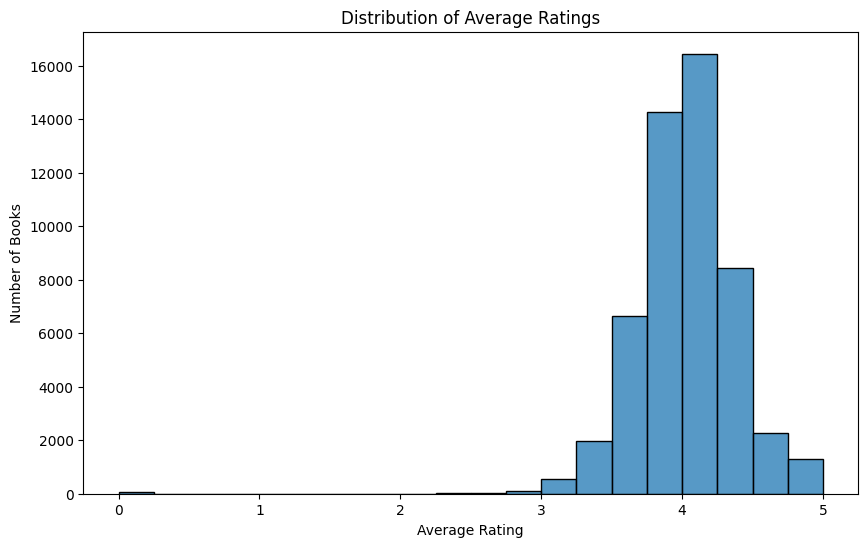

In [ ]:
#Average Ratings
plt.figure(figsize=(10, 6))
sns.histplot(books['average_rating'], bins=20)
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.savefig('images/rating_dist.png')

                         author  count
0                  Nora Roberts     87
1               Agatha Christie     74
2                  Stephen King     66
3                   Erin Hunter     57
4                     Meg Cabot     55
5                 Bella Forrest     53
6                   Lucian Bane     49
7               Karen Kingsbury     49
8               Terry Pratchett     48
9                    NOT A BOOK     48
10                Bonnie Bryant     47
11              Mercedes Lackey     47
12             Sherrilyn Kenyon     45
13                  Enid Blyton     45
14  Will Durant, Ariel Durant,      44


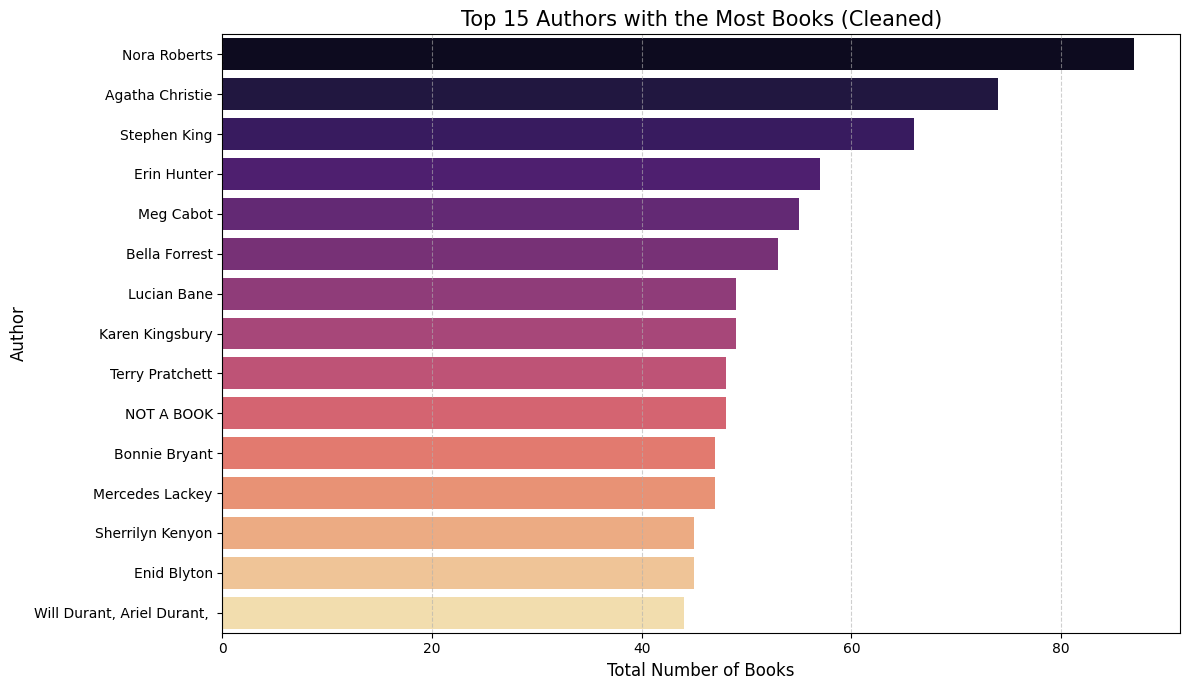

In [ ]:

#I saw lot of authors has space as value.  Filter those out. 
#That analysis has been added in one of the previous code cell.

#Just filtering spaces I saw that comma is also one of the author in the list so I am ignoring that too.
#'NOT A BOOK' is usually some articles 
#clean_books = books[books['author'].str.strip() != "" ]
invalid_authors = ["", " ", ","]
clean_books = books[(books['author'].str.strip() != "") & (books['author'].str.strip() != ",")]

top_prolific_authors = clean_books['author'].value_counts().head(15).reset_index()
print (top_prolific_authors)
top_prolific_authors.columns = ['author', 'book_count']

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_prolific_authors, 
    x='book_count', 
    y='author', 
    palette='magma',
    hue='author',
    legend=False
)

plt.title('Top 15 Authors with the Most Books (Cleaned)', fontsize=15)
plt.xlabel('Total Number of Books', fontsize=12)
plt.ylabel('Author', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

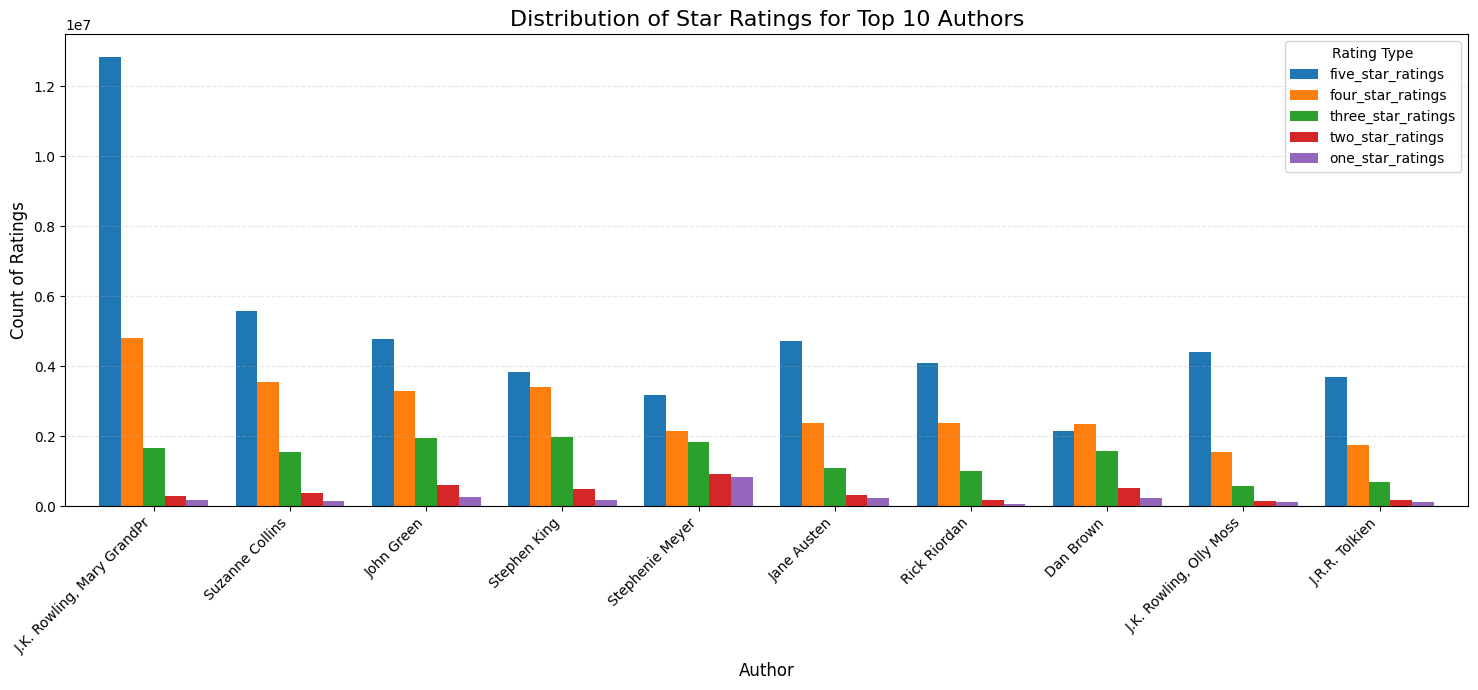

In [ ]:
#Top 10 authors star distibution
#We can see 'J K Rowling' is here twice for 'Harry Potter' series for diffent editions with it's atrist. 
star_cols = ['five_star_ratings', 'four_star_ratings', 'three_star_ratings', 'two_star_ratings', 'one_star_ratings']
author_stars = books.groupby('author')[star_cols].sum()

top_10_authors = books.groupby('author')['rating_count'].sum().nlargest(10).index
plot_data = author_stars.loc[top_10_authors]

ax = plot_data.plot(kind='bar', figsize=(15, 7), width=0.8)

plt.title('Distribution of Star Ratings for Top 10 Authors', fontsize=16)
plt.ylabel('Count of Ratings', fontsize=12)
plt.xlabel('Author', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Rating Type")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

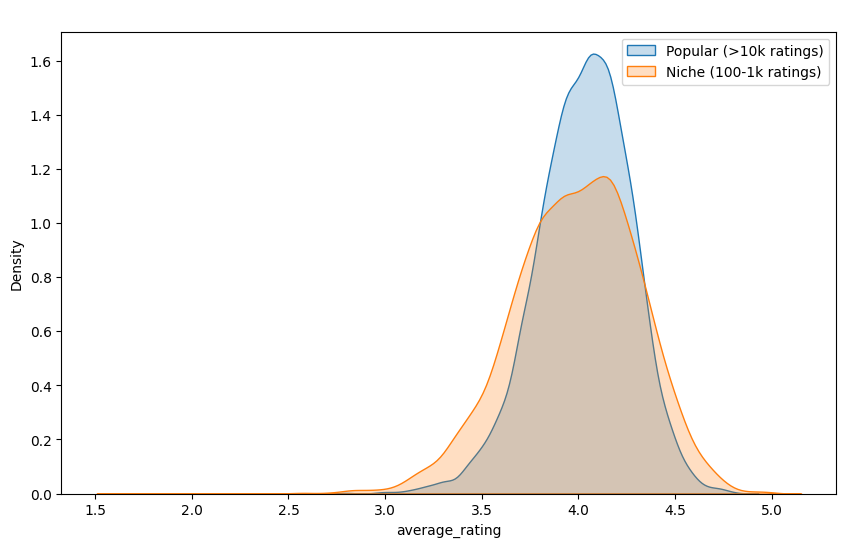

In [ ]:
#Popular books vs niche books
popular = books[books['rating_count'] > 10000]['average_rating']
niche = books[(books['rating_count'] > 100) & (books['rating_count'] <= 1000)]['average_rating']

plt.figure(figsize=(10, 6))
sns.kdeplot(popular, label='Popular (>10k ratings)', fill=True)
sns.kdeplot(niche, label='Niche (100-1k ratings)', fill=True)
plt.title(' ')
plt.legend()
plt.show()

publisher
Vintage                                        572
HarperCollins                                  562
Penguin Books                                  502
Ballantine Books                               396
Bantam                                         374
Createspace Independent Publishing Platform    368
Pocket Books                                   318
Avon                                           307
Simon  Schuster                                300
Del Rey                                        287
Name: count, dtype: int64


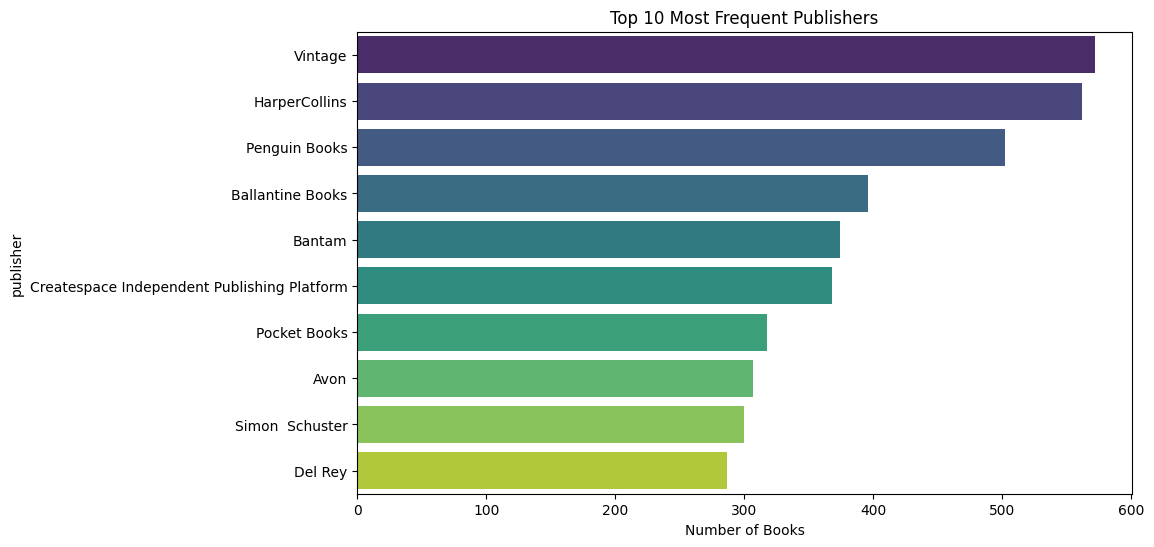

In [ ]:

#Top 10 frequent Publishers. Ignoring others as it comes as top publisher as in clean up we replaced all spaces and NaN with 'Other'
filtered_publishers = books[books['publisher'] != 'Other']['publisher']
top_publishers = filtered_publishers.value_counts().nlargest(10)
print (top_publishers)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, hue=top_publishers.index, palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Publishers')
plt.xlabel('Number of Books')
plt.show()


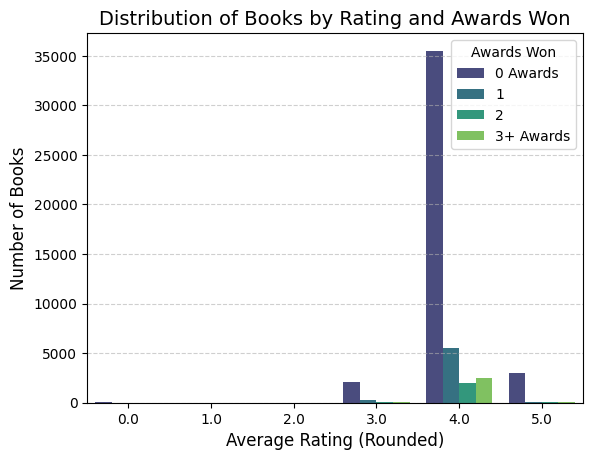

In [49]:
rating_bins = books['average_rating'].round()
award_groups = books['award_count'].apply(lambda x: '0 Awards' if x == 0 else (str(x) if x < 3 else '3+ Awards'))
sns.countplot(
    x=rating_bins, 
    hue=award_groups, 
    hue_order=['0 Awards', '1', '2', '3+ Awards'],
    palette='viridis'
)
plt.title('Distribution of Books by Rating and Awards Won', fontsize=14)
plt.xlabel('Average Rating (Rounded)', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.legend(title='Awards Won')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


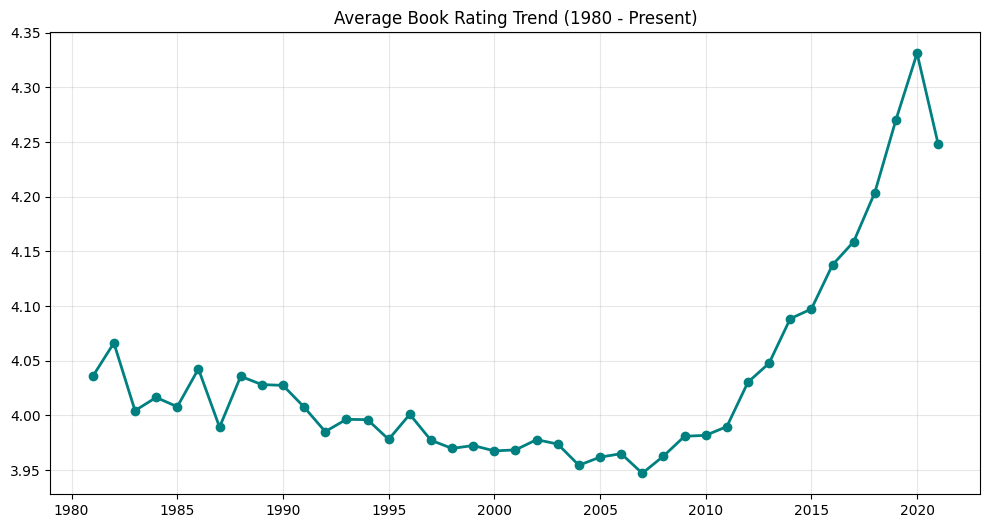

In [ ]:
#Rating Trend Over Time (Since 1980). We will us the column which we added 'year_published'
plt.figure(figsize=(12, 6))
yearly_trend = books[books['year_published'] > 1980].groupby('year_published')['average_rating'].mean()
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', color='teal', linewidth=2)
plt.title('Average Book Rating Trend (1980 - Present)')
plt.grid(True, alpha=0.3)

[Back to top](#-Index)

### Modeling

 Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [31]:
print(books.info())


<class 'pandas.core.frame.DataFrame'>
Index: 52193 entries, 0 to 52198
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           52193 non-null  int64  
 1   title                        52193 non-null  object 
 2   link                         52193 non-null  object 
 3   series                       23318 non-null  object 
 4   author                       52193 non-null  object 
 5   author_link                  52193 non-null  object 
 6   rating_count                 52193 non-null  int64  
 7   review_count                 52193 non-null  int64  
 8   average_rating               52193 non-null  float64
 9   five_star_ratings            52193 non-null  int64  
 10  four_star_ratings            52193 non-null  int64  
 11  three_star_ratings           52193 non-null  int64  
 12  two_star_ratings             52193 non-null  int64  
 13  one_star_ratings     

In [32]:
#Grouping the authors who has less number of books to reduce the variation in number of authors. 
author_counts = books['author'].value_counts()
top_authors = author_counts[author_counts >= 10].index
books['author_grouped'] = books['author'].apply(lambda x: x if x in top_authors else 'Other Author')

#Grouping the authors who has less number of books to reduce the variation in number of authors. 
pub_counts = books['publisher'].value_counts()
top_pubs = pub_counts[pub_counts >= 20].index
books['publisher_grouped'] = books['publisher'].apply(lambda x: x if x in top_pubs else 'Other Publisher')


In [ ]:
#Without star_rating columns
#books_model_1_col = ['author','rating_count','review_count','is_series','no_of_other_books_in_series']
#books_model_1_col = ['author','publisher','primary_genre','rating_count','review_count','is_series','no_of_other_books_in_series']
#books_model_1_col = ['author_grouped','publisher_grouped','primary_genre','rating_count','review_count','is_series','no_of_other_books_in_series']
#Without any ratings info
#books_model_1_col = ['author','publisher','primary_genre','is_series','no_of_other_books_in_series']

books_model_1_col = ['author','publisher','primary_genre','is_series','no_of_other_books_in_series','year_published']

books_model_X_1 = books[books_model_1_col].copy()
y_1 = books['is_high_rated']


X_train, X_test, y_train, y_test = train_test_split(books_model_X_1, y_1, test_size=0.3, random_state=22)

categorical_columns = books_model_X_1.select_dtypes(include=['object']).columns.tolist()
numerical_columns = books_model_X_1.select_dtypes(include=['float64', 'int64']).columns.tolist()
print (categorical_columns)
print (numerical_columns)


['author', 'publisher', 'primary_genre']
['is_series', 'no_of_other_books_in_series', 'year_published']


Accuracy: 0.7083918763571337
[[5033 2270]
 [2296 6059]]


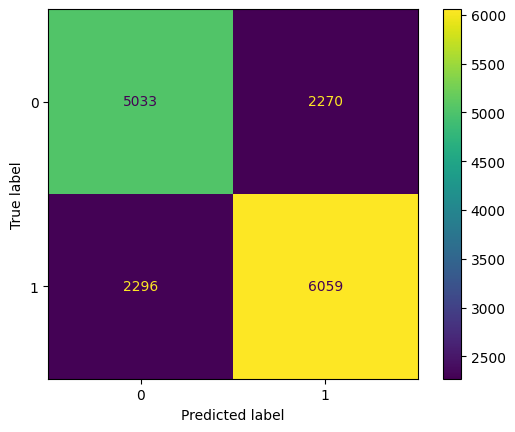

In [ ]:
processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

lg_eco = Pipeline([
    ('prep', processor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'))
])
lg_eco.fit(X_train, y_train)
y_pred = lg_eco.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print (f"Accuracy: {accuracy}")
print (conf_matrix)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot()

#This model's accuracy is around 70.8%. 
#Here we built a model which uses book's metadata like author, publisher, genre, year of publishing, part of series and no of books in the series to predict whether book will be rated high or not

#I tried all the commented columns dataset from previous cell of code with same model above and I am always getting results ~70% meaning with provided columns the model has converged and now stable. 
#We need to use some other columns and models to come up with better results. But even the current model can be used by marketing/sales team to predict and target which books to market more on and can have higher sales